# Composer Classification Using LSTM and CNN

## Team Members

## Introduction

Music by different composers carries distinctive stylistic patterns. This project applies deep learning to identify the composer of a musical score from its MIDI representation, using nine classical composers: Bach, Bartók, Byrd, Chopin, Handel, Hummel, Mendelssohn, Mozart, and Schumann. Two architectures are used, a Long Short-Term Memory (LSTM) network and a Convolutional Neural Network (CNN), each trained on features extracted from the scores.

## Objective

The objective is to build and compare deep learning models that predict the composer of a musical score. The work follows a standard pipeline: collecting and inspecting the data, pre-processing the MIDI files, extracting musical features, and then building, training, evaluating, and tuning the LSTM and CNN models.

## Dataset

The dataset consists of MIDI files from the nine composers listed above, provided already divided into training, development, and test sets. Each file is a score labeled with its composer. The scores vary considerably in length and in the number of instruments, which the pre-processing and feature-extraction steps take into account.

*The dataset and the extracted features are included in this repository, so the notebook runs without any manual file downloads.*

## Import Libraries

In [1]:
# Install dependencies — runs on local Jupyter and on Google Colab
%pip install -q music21 pretty_midi numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, glob, json, warnings
from collections import OrderedDict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi

warnings.filterwarnings("ignore")   # MIDI files trigger many harmless parser warnings
pd.set_option("display.max_columns", None)
print("Libraries loaded. numpy", np.__version__, "| pretty_midi", pretty_midi.__version__)

Libraries loaded. numpy 1.26.4 | pretty_midi 0.2.11


In [ ]:
# ---- Environment-aware paths: works on a local machine or in Google Colab ----
# The notebook locates the project automatically rather than relying on a fixed path:
#   - Local : finds the 'composer-id' folder relative to this notebook.
#   - Colab : clones the project (dataset and features included) from GitHub,
#             falling back to Google Drive if needed.

import os, sys, zipfile

REPO_DIRNAME = "composer-id"
DATA_SUBPATH = os.path.join("data", "NN_midi_files_extended")
REPO_URL     = "https://github.com/AAi511-Group3-Music-Project/musicproject.git"

IN_COLAB = "google.colab" in sys.modules

def has_data(root):
    """True if `root` looks like the project root (contains the dataset)."""
    return bool(root) and os.path.isdir(os.path.join(root, DATA_SUBPATH))

def find_repo_root():
    """Search nearby and upward from the working directory for the dataset folder."""
    start = os.getcwd()
    candidates = [start, os.path.join(start, REPO_DIRNAME), os.path.dirname(start)]
    p = start
    for _ in range(6):                       # walk up a few levels (handles the notebooks/ subdir)
        candidates.append(p); p = os.path.dirname(p)
    for c in candidates:
        if has_data(c):
            return os.path.abspath(c)
    return None

REPO_ROOT = find_repo_root()

# ---- Google Colab: obtain the project from GitHub (or Google Drive as a fallback) ----
if REPO_ROOT is None and IN_COLAB:
    # clone the public repository (the dataset and features are included in it)
    target = f"/content/{REPO_DIRNAME}"
    if not has_data(target):
        os.system(f"git clone {REPO_URL} {target}")
    if has_data(target):
        REPO_ROOT = target

    # fallback: a 'composer-id' folder or 'composer-id.zip' placed in Google Drive
    if REPO_ROOT is None:
        from google.colab import drive
        drive.mount("/content/drive")
        mydrive = "/content/drive/MyDrive"
        for c in [f"{mydrive}/{REPO_DIRNAME}", mydrive, f"{mydrive}/Colab Notebooks/{REPO_DIRNAME}"]:
            if has_data(c):
                REPO_ROOT = c; break
        if REPO_ROOT is None and os.path.exists(f"{mydrive}/{REPO_DIRNAME}.zip"):
            with zipfile.ZipFile(f"{mydrive}/{REPO_DIRNAME}.zip") as z:
                z.extractall("/content")
            if has_data(target):
                REPO_ROOT = target

assert REPO_ROOT is not None, (
    "Could not locate the dataset.\n"
    "  - Local: open this notebook from inside the 'composer-id' folder.\n"
    "  - Colab: run this on Colab so the project can be cloned from GitHub, or place\n"
    f"    'composer-id.zip' in Google Drive so that '{DATA_SUBPATH}' exists, then re-run.")

DATA_DIR     = os.path.join(REPO_ROOT, DATA_SUBPATH)
FEATURES_DIR = os.path.join(REPO_ROOT, "features")
os.makedirs(FEATURES_DIR, exist_ok=True)

print("Running on Colab:", IN_COLAB)
print("REPO_ROOT   :", REPO_ROOT)
print("DATA_DIR    :", DATA_DIR)
print("FEATURES_DIR:", FEATURES_DIR)

In [4]:
# ---- Configuration (all tunable knobs live here) ----
SPLITS = ["train", "dev", "test"]

# Pitch / piano-roll (CNN input)
PITCH_LO, PITCH_HI = 21, 108     # 88 piano keys (A0..C8); notes outside are clipped
N_PITCHES = PITCH_HI - PITCH_LO + 1   # 88
FS         = 6                   # piano-roll frames per second
ROLL_W     = 96                  # frames per window (~16 s)
ROLL_HOP   = 96                  # hop between windows (non-overlapping)

# Token sequences (LSTM input)
QUANT   = 0.125                  # onset quantization grid in seconds
SEQ_LEN = 100                    # tokens per window
SEQ_HOP = 100                    # hop between windows (non-overlapping)
VOCAB_SIZE = 500                 # keep the most frequent note/chord tokens; rest -> <UNK>
PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"

# Cleaning
MIN_NOTES = 50                   # drop MIDI files with fewer real notes than this

# Data augmentation (Section 2) — TRAIN ONLY
AUG_SHIFTS = [-2, -1, 1, 2]      # semitone transpositions added to the training set

# Limit files per composer for a quick smoke-test run (None = use everything)
MAX_FILES_PER_CLASS = None

print("Config ready. 88-key roll, FS=%d, ROLL_W=%d, SEQ_LEN=%d, vocab<=%d" % (FS, ROLL_W, SEQ_LEN, VOCAB_SIZE))

Config ready. 88-key roll, FS=6, ROLL_W=96, SEQ_LEN=100, vocab<=500


## Load Dataset

The files are organized by composer and by split. This step reads the directory into an inventory table that records, for every file, its split, composer, and path.

In [5]:
# Walk the dataset directory into a tidy inventory table
rows = []
for split in SPLITS:
    for composer in sorted(os.listdir(os.path.join(DATA_DIR, split))):
        cdir = os.path.join(DATA_DIR, split, composer)
        if not os.path.isdir(cdir):
            continue
        files = sorted(glob.glob(os.path.join(cdir, "*.mid")))
        if MAX_FILES_PER_CLASS:
            files = files[:MAX_FILES_PER_CLASS]
        for f in files:
            rows.append({"split": split, "composer": composer, "path": f,
                         "filename": os.path.basename(f)})

inventory = pd.DataFrame(rows)
COMPOSERS = sorted(inventory["composer"].unique())
print(f"{len(inventory)} MIDI files | {len(COMPOSERS)} composers: {COMPOSERS}")
inventory.head()

439 MIDI files | 9 composers: ['bach', 'bartok', 'byrd', 'chopin', 'handel', 'hummel', 'mendelssohn', 'mozart', 'schumann']


,split,composer,path,filename
0,train,bach,/private/tmp/claude-501/-Users-thiagoaurvallea...,bach342.mid
1,train,bach,/private/tmp/claude-501/-Users-thiagoaurvallea...,bach343.mid
2,train,bach,/private/tmp/claude-501/-Users-thiagoaurvallea...,bach345.mid
3,train,bach,/private/tmp/claude-501/-Users-thiagoaurvallea...,bach346.mid
4,train,bach,/private/tmp/claude-501/-Users-thiagoaurvallea...,bach347.mid


## Data Exploration

The counts below summarize how many scores are available for each composer and split, and a readability check confirms that every MIDI file can be parsed and reports basic statistics on note counts and durations.

In [6]:
# Counts per composer per split
counts = (inventory.pivot_table(index="composer", columns="split",
                                values="filename", aggfunc="count", fill_value=0))
counts = counts.reindex(columns=[s for s in SPLITS if s in counts.columns])
counts["TOTAL"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum(axis=0)
counts

split,train,dev,test,TOTAL
composer,,,,
bach,42,4,4,50
bartok,41,4,4,49
byrd,42,4,4,50
chopin,41,4,4,49
handel,41,4,4,49
hummel,42,4,4,50
mendelssohn,41,4,4,49
mozart,41,4,4,49
schumann,38,3,3,44


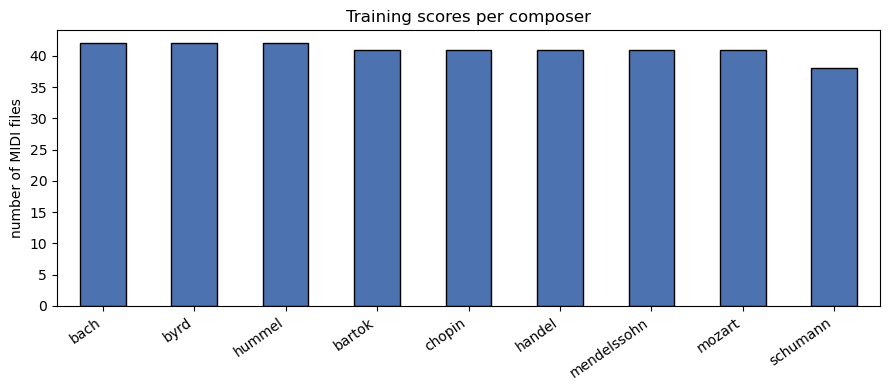

Most/least frequent training class ratio: 1.11x  (near 1.0 = well balanced)


In [7]:
# Visualize the class distribution (train split)
train_counts = counts.drop(index="TOTAL")["train"].sort_values(ascending=False)
ax = train_counts.plot(kind="bar", figsize=(9, 4), color="#4C72B0", edgecolor="black")
ax.set_title("Training scores per composer")
ax.set_ylabel("number of MIDI files"); ax.set_xlabel("")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

imb = train_counts.max() / train_counts.min()
print(f"Most/least frequent training class ratio: {imb:.2f}x  (near 1.0 = well balanced)")

In [8]:
# Integrity check: confirm every file is a parseable MIDI and record basic stats
def quick_stats(path):
    try:
        pm = pretty_midi.PrettyMIDI(path)
        n_notes = sum(len(i.notes) for i in pm.instruments if not i.is_drum)
        return pd.Series({"ok": True, "n_instruments": len(pm.instruments),
                          "n_notes": n_notes, "duration_s": pm.get_end_time()})
    except Exception as e:
        return pd.Series({"ok": False, "n_instruments": 0, "n_notes": 0,
                          "duration_s": 0.0, "error": type(e).__name__})

stats = inventory["path"].apply(quick_stats)
inventory = pd.concat([inventory, stats], axis=1)

n_bad = int((~inventory["ok"]).sum())
print(f"Readable: {int(inventory['ok'].sum())}/{len(inventory)}   |   Corrupt/unreadable: {n_bad}")
print("\nNote-count & duration summary (readable files):")
inventory.loc[inventory["ok"], ["n_notes", "n_instruments", "duration_s"]].describe().round(1)

Readable: 439/439   |   Corrupt/unreadable: 0

Note-count & duration summary (readable files):


,n_notes,n_instruments,duration_s
count,439.0,439.0,439.0
mean,3897.3,6.6,323.0
std,4657.2,6.6,303.0
min,109.0,1.0,26.7
25%,977.5,1.0,119.6
50%,2192.0,4.0,230.9
75%,5026.5,11.0,428.3
max,31879.0,50.0,2130.7


### Observations

- The dataset contains nine composers, provided already divided into training, development, and test sets.
- The classes are approximately balanced, at roughly 44 to 50 scores each, so overall accuracy is a meaningful headline metric, complemented by precision and recall during evaluation.
- Score length and density vary considerably, from around one hundred notes to over thirty thousand, and from under a minute to more than thirty minutes. Using an entire score as a single input is therefore impractical, and each score is divided into fixed-size windows during feature extraction.
- Any unreadable or near-empty files identified here are removed during pre-processing.

## Data Preprocessing

Pre-processing converts the raw MIDI files into clean and consistent material for feature extraction. Each score is loaded with *pretty_midi*, unreadable and near-empty files are removed, and drum tracks are excluded because they are unpitched and not characteristic of a composer. The scores are not transposed to a common key, since key and modulation form part of a composer's style and normalizing them could remove useful signal.

In [9]:
def load_midi(path):
    """Load a MIDI file, returning None if it cannot be parsed."""
    try:
        return pretty_midi.PrettyMIDI(path)
    except Exception:
        return None

def pitched_notes(pm):
    """All (start, pitch) pairs from non-drum instruments, time-sorted."""
    notes = [(n.start, n.pitch) for inst in pm.instruments if not inst.is_drum
             for n in inst.notes]
    notes.sort()
    return notes

def is_usable(pm):
    """Keep only scores with enough real pitched content."""
    return pm is not None and len(pitched_notes(pm)) >= MIN_NOTES

In [10]:
# Apply cleaning to the inventory
clean = inventory[inventory["ok"]].copy()
clean = clean[clean["n_notes"] >= MIN_NOTES].reset_index(drop=True)

dropped = len(inventory) - len(clean)
print(f"Kept {len(clean)} / {len(inventory)} files  ({dropped} dropped: unreadable or < {MIN_NOTES} notes)")
clean.groupby(["composer", "split"]).size().unstack(fill_value=0)

Kept 439 / 439 files  (0 dropped: unreadable or < 50 notes)


split,dev,test,train
composer,,,
bach,4,4,42
bartok,4,4,41
byrd,4,4,42
chopin,4,4,41
handel,4,4,41
hummel,4,4,42
mendelssohn,4,4,41
mozart,4,4,41
schumann,3,3,38


## Data Augmentation

The training set is expanded through pitch transposition, shifting each piece up or down by a few semitones. Transposition preserves a composer's melodic and harmonic style while adding variety and increasing the amount of training data. It is applied to the training set only, so the development and test sets remain an honest measure of generalization. The transposition functions are defined here and applied during feature extraction.

In [11]:
# ---- Data augmentation primitives (used here for demo; applied for real in Section 3) ----
def transpose_notes(notes, semitones):
    """Shift a list of (start, pitch) by N semitones; drop notes that fall off the 0..127 MIDI range."""
    out = [(s, p + semitones) for (s, p) in notes if 0 <= p + semitones <= 127]
    return out

def transpose_roll(roll, semitones):
    """Shift an 88 x T piano-roll up/down by N semitones, zero-filling vacated keys."""
    shifted = np.zeros_like(roll)
    if semitones == 0:
        return roll.copy()
    if semitones > 0:
        shifted[semitones:, :] = roll[:-semitones, :]
    else:
        shifted[:semitones, :] = roll[-semitones:, :]
    return shifted

# Demo: how augmentation changes the pitch content of one real file
demo_pm = load_midi(clean.iloc[0]["path"])
base = pitched_notes(demo_pm)
print("Example file:", clean.iloc[0]["filename"])
print("original first 8 pitches:", [p for _, p in base[:8]])
for k in AUG_SHIFTS:
    print(f"transpose {k:+d}:            ", [p for _, p in transpose_notes(base, k)[:8]])
print(f"\nEach training file yields 1 original + {len(AUG_SHIFTS)} transposed copies "
      f"= {1+len(AUG_SHIFTS)}x more training windows.")

Example file: bach342.mid
original first 8 pitches: [45, 49, 52, 57, 56, 54, 52, 56]
transpose -2:             [43, 47, 50, 55, 54, 52, 50, 54]
transpose -1:             [44, 48, 51, 56, 55, 53, 51, 55]
transpose +1:             [46, 50, 53, 58, 57, 55, 53, 57]
transpose +2:             [47, 51, 54, 59, 58, 56, 54, 58]

Each training file yields 1 original + 4 transposed copies = 5x more training windows.


## Feature Extraction

Two aligned representations are extracted from each score and saved to the *features* directory.

**Note and chord sequences.** Notes are quantized onto a time grid. Notes that share an onset form a chord token, for example *60.64.67*, while a single note forms a note token, for example *60*. The resulting stream is encoded using a vocabulary of the most frequent tokens and divided into fixed-length windows. This representation is used by the LSTM.

**Piano-roll matrices.** A binary grid of 88 keys by time frames records which pitches sound at each moment. It is divided into fixed-size windows and used by the CNN.

To illustrate the musical content underlying these encodings, *music21* is used to extract the estimated key, tempo, and opening chords of a sample score.

In [12]:
# ---- Extraction functions ----
def event_sequence(pm):
    """MIDI -> list of note/chord string tokens, quantized onto a QUANT-second grid."""
    notes = pitched_notes(pm)
    groups = OrderedDict()
    for start, pitch in notes:
        q = round(start / QUANT)
        groups.setdefault(q, set()).add(pitch)
    tokens = []
    for q in sorted(groups):
        ps = sorted(groups[q])
        tokens.append(str(ps[0]) if len(ps) == 1 else ".".join(map(str, ps)))
    return tokens

def piano_roll(pm):
    """MIDI -> binary 88 x T piano-roll cropped to the 88-key range."""
    pr = pm.get_piano_roll(fs=FS)[PITCH_LO:PITCH_HI + 1]
    return (pr > 0).astype(np.uint8)

def window_sequence(int_tokens):
    """Slice an int-encoded token list into fixed SEQ_LEN windows (last one zero-padded)."""
    out = []
    for i in range(0, max(1, len(int_tokens)), SEQ_HOP):
        w = int_tokens[i:i + SEQ_LEN]
        if len(w) < SEQ_LEN:
            w = w + [0] * (SEQ_LEN - len(w))     # 0 == <PAD>
        out.append(w)
        if i + SEQ_LEN >= len(int_tokens):
            break
    return out

def window_roll(roll):
    """Slice an 88 x T roll into fixed 88 x ROLL_W windows (last one zero-padded)."""
    out, T = [], roll.shape[1]
    for i in range(0, max(1, T), ROLL_HOP):
        w = roll[:, i:i + ROLL_W]
        if w.shape[1] < ROLL_W:
            w = np.pad(w, ((0, 0), (0, ROLL_W - w.shape[1])))
        out.append(w)
        if i + ROLL_W >= T:
            break
    return out

print("Extraction functions defined.")

Extraction functions defined.


In [13]:
# ---- Illustration: music21 as a music-analysis tool (one sample file) ----
from music21 import converter, chord, note

sample_path = clean.iloc[0]["path"]
try:
    s = converter.parse(sample_path)
    key = s.analyze("key")
    tempos = s.metronomeMarkBoundaries()
    tempo_bpm = tempos[0][2].number if tempos else "n/a"
    ch = s.chordify()
    chord_names = []
    for el in ch.recurse().getElementsByClass(chord.Chord):
        chord_names.append(el.pitchedCommonName)
        if len(chord_names) >= 6:
            break
    print("music21 analysis of", os.path.basename(sample_path))
    print("  estimated key :", key)
    print("  first tempo   :", tempo_bpm, "BPM")
    print("  first chords  :", chord_names)
except Exception as e:
    print("music21 illustration skipped:", type(e).__name__, e)

music21 analysis of bach342.mid
  estimated key : A major
  first tempo   : 120 BPM
  first chords  : ['A', 'Major Third above A', 'A-major triad', 'Perfect Fifth above A', 'Perfect Fifth with octave doublings above A', 'A']


In [14]:
# ---- Build the token vocabulary from the TRAIN split only ----
train_paths = clean.loc[clean["split"] == "train", "path"].tolist()

counter = Counter()
for p in train_paths:
    pm = load_midi(p)
    if pm is not None:
        counter.update(event_sequence(pm))

most_common = [tok for tok, _ in counter.most_common(VOCAB_SIZE)]
itos = [PAD_TOKEN, UNK_TOKEN] + most_common          # index -> token
stoi = {tok: i for i, tok in enumerate(itos)}        # token -> index
UNK_IDX = stoi[UNK_TOKEN]

def encode(tokens):
    return [stoi.get(t, UNK_IDX) for t in tokens]

print(f"Vocabulary: {len(itos)} tokens (incl. <PAD>,<UNK>). "
      f"{len(counter)} distinct tokens seen; kept top {len(most_common)}.")
print("Sample tokens:", itos[2:12])

Vocabulary: 502 tokens (incl. <PAD>,<UNK>). 55851 distinct tokens seen; kept top 500.
Sample tokens: ['74', '69', '72', '67', '62', '76', '71', '64', '79', '60']


In [15]:
# ---- Extract features for every split; augment TRAIN with transpositions ----
label_map = {c: i for i, c in enumerate(COMPOSERS)}

def build_split(split):
    df = clean[clean["split"] == split]
    seqs, seq_y, rolls, roll_y = [], [], [], []
    # Only the training split is augmented
    shifts = [0] + AUG_SHIFTS if split == "train" else [0]
    for _, r in df.iterrows():
        pm = load_midi(r["path"])
        if pm is None:
            continue
        y = label_map[r["composer"]]
        notes = pitched_notes(pm)
        base_roll = piano_roll(pm)
        for k in shifts:
            # --- sequence representation ---
            nk = transpose_notes(notes, k)
            groups = OrderedDict()
            for start, pitch in nk:
                groups.setdefault(round(start / QUANT), set()).add(pitch)
            toks = [ (str(sorted(v)[0]) if len(v) == 1 else ".".join(map(str, sorted(v))))
                     for q, v in sorted(groups.items()) ]
            for w in window_sequence(encode(toks)):
                seqs.append(w); seq_y.append(y)
            # --- piano-roll representation ---
            rk = transpose_roll(base_roll, k)
            for w in window_roll(rk):
                rolls.append(w); roll_y.append(y)
    X_seq  = np.asarray(seqs,  dtype=np.int32)
    y_seq  = np.asarray(seq_y, dtype=np.int32)
    X_roll = np.asarray(rolls, dtype=np.uint8)
    y_roll = np.asarray(roll_y, dtype=np.int32)
    return X_seq, y_seq, X_roll, y_roll

features = {}
for split in SPLITS:
    Xs, ys, Xr, yr = build_split(split)
    features[split] = dict(X_seq=Xs, y_seq=ys, X_roll=Xr, y_roll=yr)
    print(f"{split:5s}: seq {Xs.shape} | roll {Xr.shape}  "
          f"({'augmented' if split=='train' else 'no augmentation'})")

train: seq (27170, 100) | roll (38070, 88, 96)  (augmented)


dev  : seq (499, 100) | roll (698, 88, 96)  (no augmentation)


test : seq (515, 100) | roll (758, 88, 96)  (no augmentation)


## Prepare LSTM Input Data

The saved features are reloaded through a helper function, so this stage does not depend on re-running the extraction. The LSTM uses the note and chord token sequences, *X_seq*, an integer array of shape *[N, SEQ_LEN]* that is embedded using the vocabulary size recorded in *meta*.

In [16]:
def load_features(features_dir=None):
    """Load all saved features. Returns (data, meta, label_map, vocab)."""
    features_dir = features_dir or FEATURES_DIR
    with open(os.path.join(features_dir, "meta.json")) as f:      meta = json.load(f)
    with open(os.path.join(features_dir, "label_map.json")) as f: label_map = json.load(f)
    with open(os.path.join(features_dir, "vocab.json")) as f:     vocab = json.load(f)
    data = {}
    for split in ["train", "dev", "test"]:
        shape = tuple(np.load(os.path.join(features_dir, f"{split}_roll_shape.npy")))
        roll  = np.unpackbits(np.load(os.path.join(features_dir, f"{split}_roll.npy")))
        roll  = roll[:int(np.prod(shape))].reshape(shape).astype(np.uint8)
        data[split] = dict(
            X_seq  = np.load(os.path.join(features_dir, f"{split}_seq.npy")),
            y_seq  = np.load(os.path.join(features_dir, f"{split}_seq_labels.npy")),
            X_roll = roll,
            y_roll = np.load(os.path.join(features_dir, f"{split}_roll_labels.npy")),
        )
    return data, meta, label_map, vocab

data, meta, label_map, vocab = load_features()
print("Loaded features. Composers:", label_map)
for split in ["train", "dev", "test"]:
    d = data[split]
    print(f"  {split:5s}: X_seq {d['X_seq'].shape}  X_roll {d['X_roll'].shape}")
print("\nModel inputs:")
print("  LSTM : X_seq  [N, %d]      (vocabulary size %d)" % (meta["seq_len"], meta["vocab_size"]))
print("  CNN  : X_roll [N, %d, %d, 1]" % (meta["n_pitches"], meta["roll_w"]))

Loaded features. Composers: {'bach': 0, 'bartok': 1, 'byrd': 2, 'chopin': 3, 'handel': 4, 'hummel': 5, 'mendelssohn': 6, 'mozart': 7, 'schumann': 8}
  train: X_seq (27170, 100)  X_roll (38070, 88, 96)
  dev  : X_seq (499, 100)  X_roll (698, 88, 96)
  test : X_seq (515, 100)  X_roll (758, 88, 96)

Model inputs:
  LSTM : X_seq  [N, 100]      (vocabulary size 502)
  CNN  : X_roll [N, 88, 96, 1]


In [17]:
# Inspect the LSTM inputs
itos = vocab["itos"]
lstm = data["train"]
print("X_seq :", lstm["X_seq"].shape, lstm["X_seq"].dtype, " labels:", lstm["y_seq"].shape)
print("vocabulary size:", meta["vocab_size"])
decoded = [itos[i] for i in lstm["X_seq"][0] if i != 0][:12]
print("example decoded token window:", decoded)

X_seq : (27170, 100) int32  labels: (27170,)
vocabulary size: 502
example decoded token window: ['45', '49', '52', '57', '56', '54', '52', '56', '59', '62', '61', '59']


## Prepare CNN Input Data

The CNN uses the piano-roll matrices, *X_roll*, a binary array of shape *[N, 88, ROLL_W]*. A channel dimension is added with *X_roll[..., None]* to match the input format expected by a convolutional network.

X_roll: (38070, 88, 96) uint8  labels: (38070,)
with a channel dimension: (38070, 88, 96, 1)


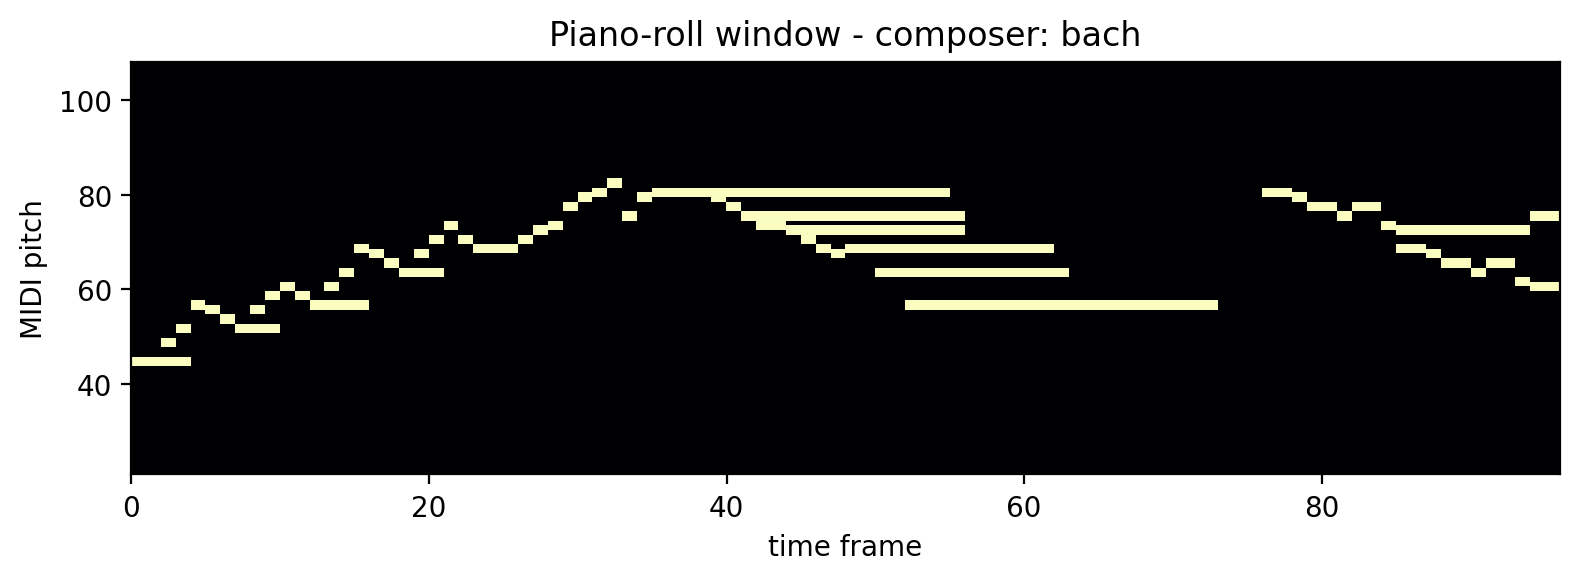

In [18]:
# Inspect the CNN inputs
cnn = data["train"]
print("X_roll:", cnn["X_roll"].shape, cnn["X_roll"].dtype, " labels:", cnn["y_roll"].shape)
print("with a channel dimension:", cnn["X_roll"][..., None].shape)

plt.figure(figsize=(8, 3))
plt.imshow(cnn["X_roll"][0], aspect="auto", origin="lower", cmap="magma",
           extent=[0, meta["roll_w"], meta["pitch_lo"], meta["pitch_hi"]])
plt.title("Piano-roll window - composer: " + meta["composers"][int(cnn["y_roll"][0])])
plt.xlabel("time frame"); plt.ylabel("MIDI pitch"); plt.tight_layout(); plt.show()

## Train, Validation, and Test Split

The dataset is provided already split into training, development, and test sets, and the extracted features preserve this split. The development set serves as the validation set during model development, and the test set is reserved for final evaluation.

In [19]:
# The dataset is provided already split; the prepared features preserve that split.
for split, role in [("train", "training"), ("dev", "validation"), ("test", "test")]:
    d = data[split]
    print(f"{role:11s}: X_seq {d['X_seq'].shape}  X_roll {d['X_roll'].shape}")

training   : X_seq (27170, 100)  X_roll (38070, 88, 96)
validation : X_seq (499, 100)  X_roll (698, 88, 96)
test       : X_seq (515, 100)  X_roll (758, 88, 96)


## LSTM Model

### Build LSTM Model

### Compile LSTM Model

### Train LSTM Model

### Evaluate LSTM Model

## CNN Model

### Build CNN Model

### Compile CNN Model

### Train CNN Model

### Evaluate CNN Model

## Model Comparison

## Hyperparameter Tuning

## Final Model Evaluation

## Results

## Discussion

## Limitations

## Conclusion

## References